# YOLOv8 Eğitimi — MacBook Pro M5 (Yerel)

`04_prepare_yolo.py` → `05_train_yolo.py` pipeline'ı yerel olarak çalıştırır.

| # | Hücre | İçerik |
|---|-------|--------|
| 1 | Kontrol | MPS, paketler, dizinler |
| 2 | Ayarlar | Tek değiştirilecek hücre |
| 3 | Ortam değişkenleri | |
| **4** | **04_prepare_yolo.py** | DICOM → PNG + YOLO etiket |
| **5** | **05_train_yolo.py** | YOLOv8 eğitimi (MPS) |
| 6 | Eğitim grafikleri | Loss, mAP, confusion matrix |
| 7 | Inference | Val seti üzerinde örnek tahmin |


## [1] Kontrol — MPS, Paketler, Dizinler

In [ ]:
import os
import sys
from pathlib import Path

PROJECT = os.environ['ABDOMEN_PROJECT_ROOT'] # Path('.').resolve()
BASE =os.environ['ABDOMEN_DATA_ROOT'] # Path('.').resolve()
OUT_DIR = os.environ['ABDOMEN_OUT_DIR'] # Path('.').resolve()


if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))


In [ ]:
import torch
mps_ok = torch.backends.mps.is_available()
print(f'PyTorch     : {torch.__version__}')
print(f'MPS         : {"OK — Apple Silicon GPU" if mps_ok else "YOK (CPU kullanılacak)"}')


In [ ]:
import ultralytics, pydicom, cv2
print(f'ultralytics : {ultralytics.__version__}')
print(f'pydicom     : {pydicom.__version__}')
print(f'OpenCV      : {cv2.__version__}')


In [ ]:



checks = {
    'Bilgi.xlsx'                      : BASE / 'Bilgi.xlsx',
    'Test Verisi/'              : BASE / 'Test Verisi',
    'abdomen_project/src/detection.py': PROJECT / 'src' / 'detection.py',
    'outputs/splits/manifest.csv'     : OUT_DIR  / 'splits' / 'manifest.csv',
}
print()
all_ok = True
for label, path in checks.items():
    ok = path.exists()
    print(f'  [{"OK" if ok else "EKSIK"}] {label}')
    if not ok: all_ok = False
print()
print('Hazır!' if all_ok else 'Eksik dosyalar var.')

PyTorch     : 2.8.0
MPS         : OK — Apple Silicon GPU
ultralytics : 8.4.38
pydicom     : 2.4.4
OpenCV      : 4.9.0

  [OK] Bilgi.xlsx
  [OK] Test Verisi/
  [OK] abdomen_project/src/detection.py
  [OK] outputs/splits/manifest.csv

Hazır!


## [2] Kullanıcı Ayarları — yalnızca bu hücreyi düzenleyin

In [ ]:
import os, sys
from pathlib import Path


TRAIN_DIR    = BASE / 'Egitim Verisi'
TEST_DIR     = BASE / 'Test Verisi'
SPLITS_DIR   = OUT_DIR / 'splits'
DET_DATA_DIR = OUT_DIR / 'det_data'
RUN_DIR      = OUT_DIR / 'runs' / 'det'

# ── Tek değiştirilecek parametre ──────────────────────────────────────────────
FOLD = 0   # 0–4
# ─────────────────────────────────────────────────────────────────────────────

# Diğer tüm eğitim parametreleri config.py DetConfig'ten gelir
from src.config import DEFAULT_DET
cfg = DEFAULT_DET

DET_DATA_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)

print(f'Base        : {BASE}')
print(f'Project     : {PROJECT}')
print(f'Train dir   : {TRAIN_DIR} [{"OK" if TRAIN_DIR.exists() else "yok"}]')
print(f'Test dir    : {TEST_DIR} [{"OK" if TEST_DIR.exists() else "EKSIK"}]')
print(f'Det data    : {DET_DATA_DIR}')
print(f'Run dir     : {RUN_DIR}')
print()
print(f'Fold        : {FOLD}')
print(f'Model       : {cfg.model}')
print(f'imgsz       : {cfg.img_size}')
print(f'batch       : {cfg.batch_size}')
print(f'epochs      : {cfg.epochs}')
print(f'workers MPS : {cfg.workers_mps}')
print(f'patience    : {cfg.patience}')


Base        : /Users/ramazanpolat/Desktop/datasets/abdomen
Project     : /Users/ramazanpolat/Desktop/datasets/abdomen
Train dir   : /Users/ramazanpolat/Desktop/datasets/abdomen/Egitim Verisi [OK]
Test dir    : /Users/ramazanpolat/Desktop/datasets/abdomen/Test Verisi [OK]
Det data    : /Users/ramazanpolat/Desktop/datasets/abdomen/outputs/det_data
Run dir     : /Users/ramazanpolat/Desktop/datasets/abdomen/outputs/runs/det

Fold        : 0
Model       : yolov8x.pt
imgsz       : 512
batch       : 16
epochs      : 50
workers MPS : 2
patience    : 20


## [3] Ortam Değişkenlerini Ayarla

In [ ]:
import os

# os.environ['ABDOMEN_PROJECT_ROOT'] = str(PROJECT_DIR)
# os.environ['ABDOMEN_DATA_ROOT']    = str(BASE)
# os.environ['ABDOMEN_TRAIN_DIR']    = str(TRAIN_DIR)
# os.environ['ABDOMEN_TEST_DIR']     = str(TEST_DIR)
# os.environ['ABDOMEN_BILGI_XLSX']   = str(BASE / 'Bilgi.xlsx')
# os.environ['ABDOMEN_SPLIT_DIR']    = str(SPLITS_DIR)
# os.environ['ABDOMEN_DET_DATA_DIR'] = str(DET_DATA_DIR)
# os.environ['ABDOMEN_OUT_DIR']      = str(PROJECT_DIR / 'outputs')

for k, v in sorted(os.environ.items()):
    if k.startswith('ABDOMEN_'):
        print(f'{k:30s} = {v}')

ABDOMEN_BILGI_XLSX             = /Users/ramazanpolat/Desktop/datasets/abdomen/Bilgi.xlsx
ABDOMEN_DATA_ROOT              = /Users/ramazanpolat/Desktop/datasets/abdomen
ABDOMEN_DET_DATA_DIR           = /Users/ramazanpolat/Desktop/datasets/abdomen/outputs/det_data
ABDOMEN_OUT_DIR                = /Users/ramazanpolat/Desktop/datasets/abdomen/outputs
ABDOMEN_PROJECT_ROOT           = /Users/ramazanpolat/Desktop/datasets/abdomen
ABDOMEN_SPLIT_DIR              = /Users/ramazanpolat/Desktop/datasets/abdomen/outputs/splits
ABDOMEN_TEST_DIR               = /Users/ramazanpolat/Desktop/datasets/abdomen/Test Verisi
ABDOMEN_TRAIN_DIR              = /Users/ramazanpolat/Desktop/datasets/abdomen/Egitim Verisi


## [4] 04_prepare_yolo.py — YOLO Dataset Hazırla

DICOM → 3 kanallı PNG + YOLO etiket dosyaları + `dataset.yaml`

In [ ]:
# ProcessPoolExecutor ile paralel çalışır (min(6, cpu_count) worker)
from src.detection import export_yolo_dataset
import src.detection as _det
_det.DET_DATA_DIR = DET_DATA_DIR

print(f'Çıktı dizini : {DET_DATA_DIR}')
print(f'Fold         : {FOLD}')
print('Export başlıyor...')

fold_dir = export_yolo_dataset(fold=FOLD, out_root=DET_DATA_DIR)
print(f'\nHazır: {fold_dir}')

for split in ('train', 'val'):
    imgs   = list((fold_dir / 'images' / split).glob('*.png'))
    labels = list((fold_dir / 'labels' / split).glob('*.txt'))
    pos    = sum(1 for f in labels if f.read_text().strip())
    print(f'  {split:5s}: {len(imgs):5d} görüntü | {pos:5d} pozitif etiket')

print('\ndataset.yaml:')
print((fold_dir / 'dataset.yaml').read_text())

## [5] 05_train_yolo.py — YOLOv8 Eğitimi


In [4]:


from src.detection import train_yolo
import src.detection as _det
_det.DET_DATA_DIR = DET_DATA_DIR

best_weights = train_yolo(
    fold=FOLD,
    cfg=cfg,
    project=str(RUN_DIR),
)

print(f"Best weights: {best_weights}")
if best_weights.exists():
    print(f"Boyut: {best_weights.stat().st_size/1e6:.1f} MB")


New https://pypi.org/project/ultralytics/8.4.48 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.38 🚀 Python-3.9.6 torch-2.8.0 MPS (Apple M5)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/ramazanpolat/Desktop/datasets/abdomen/outputs/det_data/fold0/dataset.yaml, degrees=0.0, deterministic=False, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8x.pt, momentum=0.937, mosai

## [6] Eğitim Grafiklerini Görselleştir

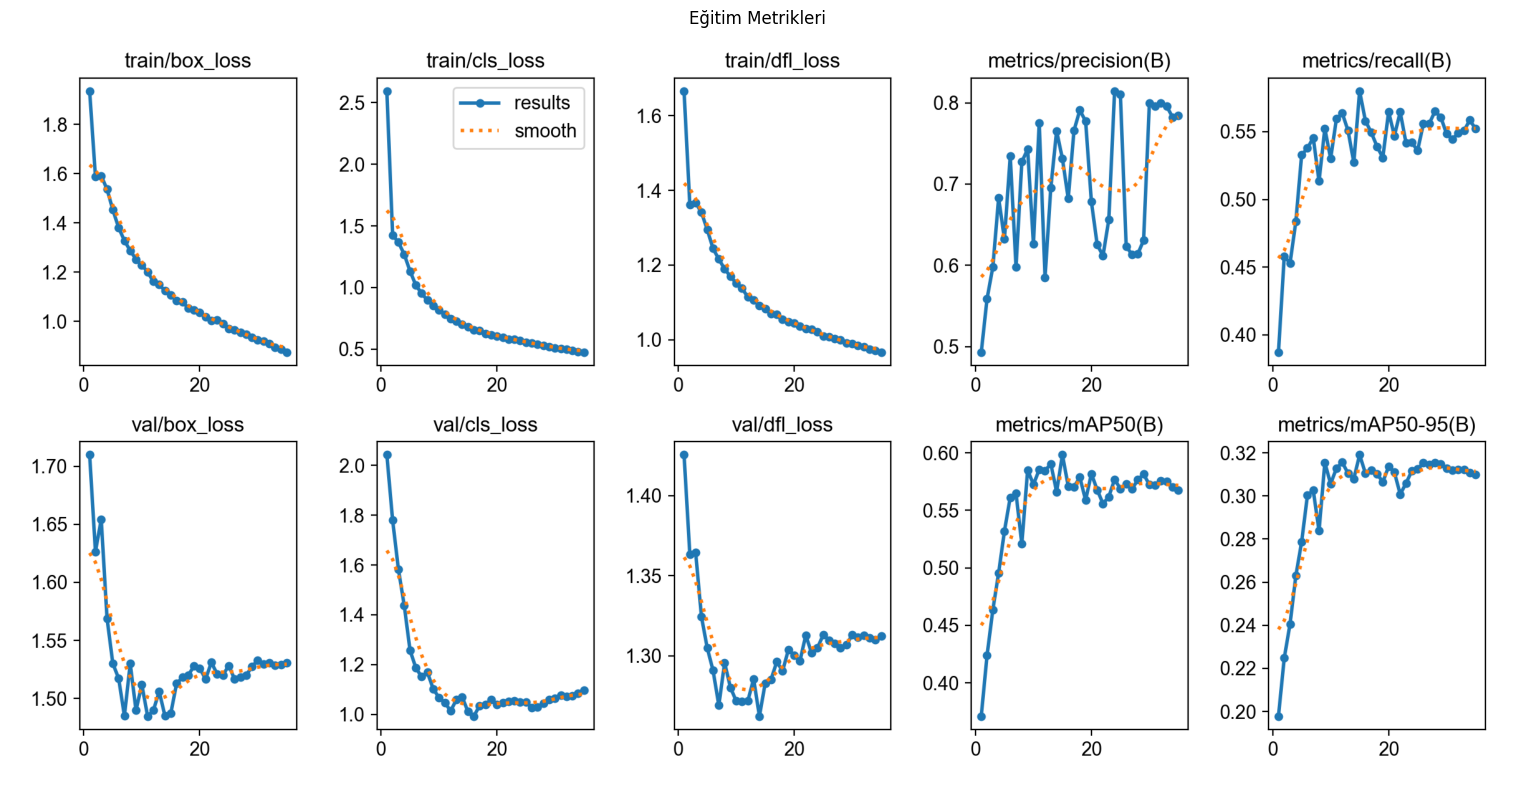

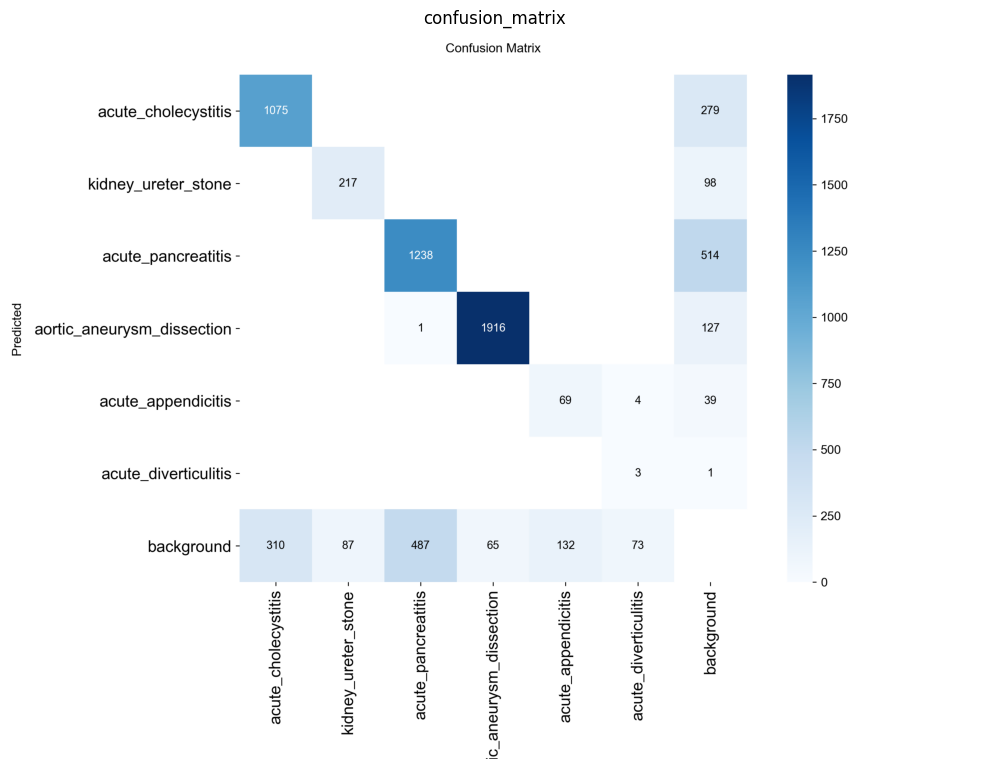

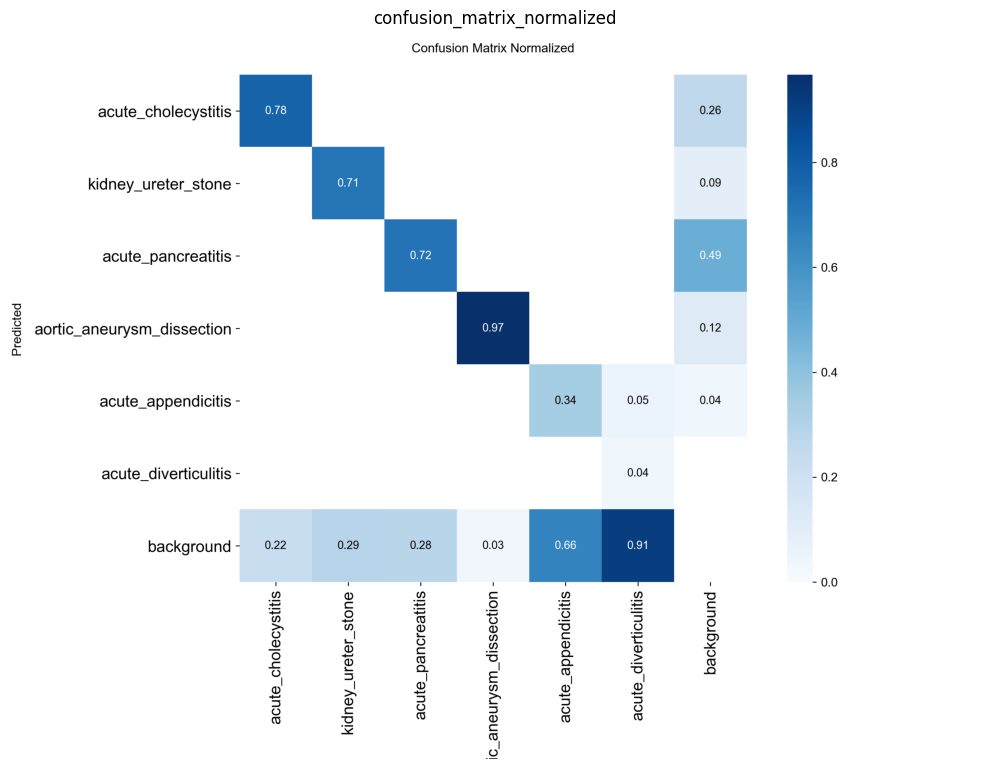

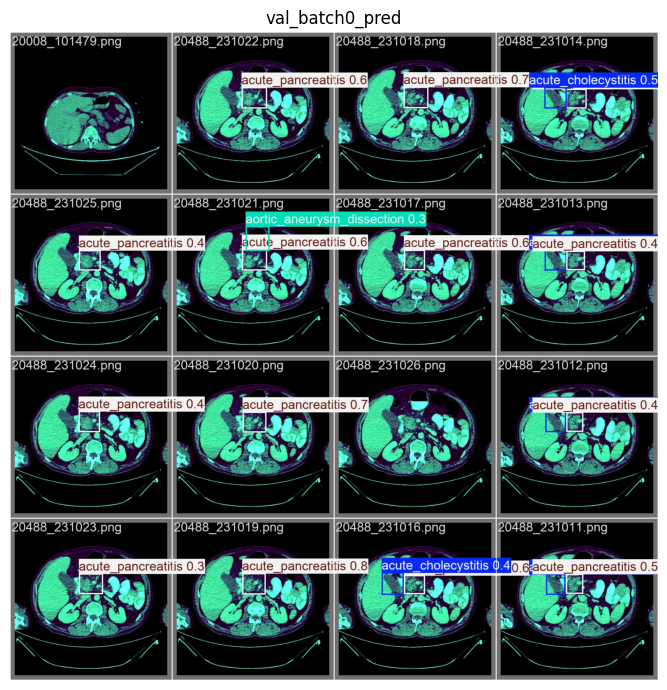

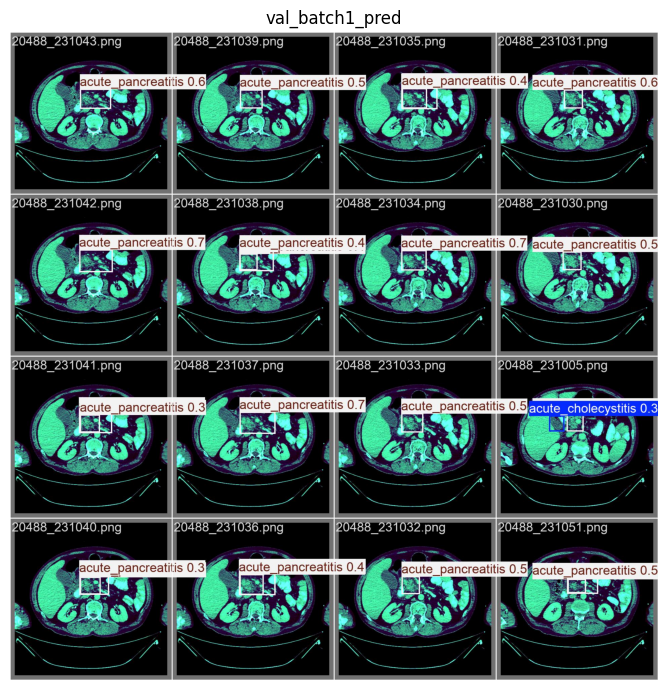


Son epoch metrikleri:
  metrics/precision(B)          : 0.7840
  metrics/recall(B)             : 0.5521
  metrics/mAP50(B)              : 0.5676
  metrics/mAP50-95(B)           : 0.3099


In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from src.config import DEFAULT_DET
from pathlib import Path
import pandas as pd

run_name = f'fold{FOLD}_{Path(DEFAULT_DET.model).stem}5'
run_dir  = RUN_DIR / run_name

def _show(path, title='', figsize=(16, 6)):
    if not path.exists():
        print(f'Bulunamadı: {path}')
        return
    img = mpimg.imread(str(path))
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.axis('off')
    if title: ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()

_show(run_dir / 'results.png', 'Eğitim Metrikleri', figsize=(18, 8))

for cm in run_dir.glob('confusion_matrix*.png'):
    _show(cm, cm.stem, figsize=(10, 9))

for vp in sorted(run_dir.glob('val_batch*_pred.jpg'))[:2]:
    _show(vp, vp.stem, figsize=(14, 7))

# Son epoch metrikleri
results_csv = run_dir / 'results.csv'
if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()
    row = df.iloc[-1]
    print('\nSon epoch metrikleri:')
    for col in ['metrics/precision(B)','metrics/recall(B)',
                'metrics/mAP50(B)','metrics/mAP50-95(B)']:
        if col in row:
            print(f'  {col:30s}: {row[col]:.4f}')

## [7] Tek Görüntü Üzerinde Inference

In [ ]:
CONF_THRESHOLD = 0.25   # Güven eşiği
N_SAMPLES      = 4      # Gösterilecek örnek sayısı

  20232_165273: acute_cholecystitis                 conf=0.594
  20334_206488: acute_cholecystitis                 conf=0.807
  20568_256707: aortic_aneurysm_dissection          conf=0.865


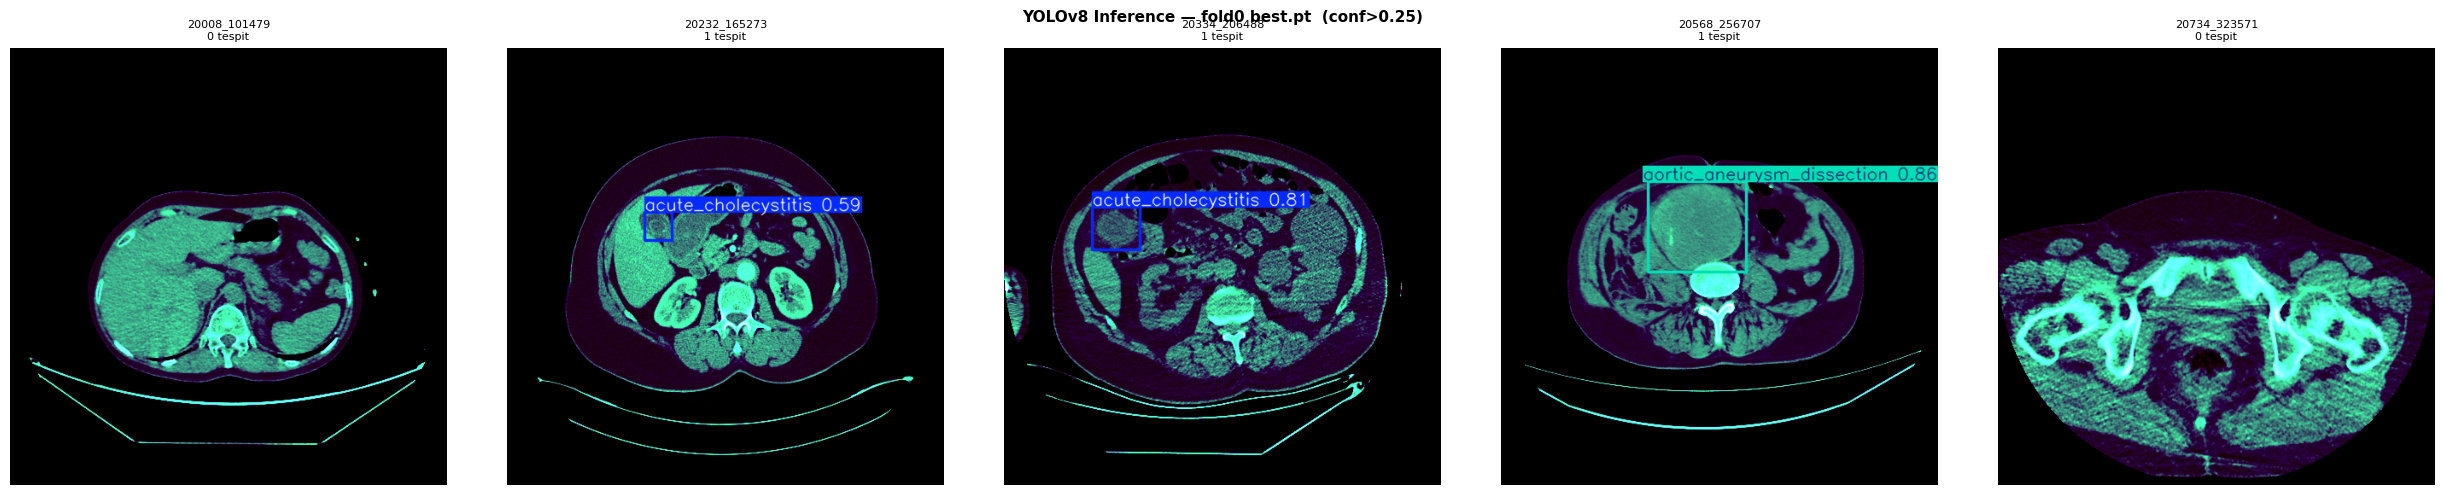

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO
from src.config import DEFAULT_DET, SUPER_CLASSES
from pathlib import Path
N_SAMPLES=5
CONF_THRESHOLD = 0.25   # Güven eşiği
run_name     = f'fold{FOLD}_{Path(DEFAULT_DET.model).stem}5'
best_weights = RUN_DIR / run_name / 'weights' / 'best.pt'

assert best_weights.exists(), f'Weights bulunamadı: {best_weights} — önce [5] çalıştırın.'

val_imgs = sorted((DET_DATA_DIR / f'fold{FOLD}' / 'images' / 'val').glob('*.png'))
if not val_imgs:
    print('Val PNG bulunamadı — önce [4] çalıştırın.')
else:
    model = YOLO(str(best_weights))

    # Eşit aralıklı N_SAMPLES örnek seç
    idxs = np.linspace(0, len(val_imgs)-1, N_SAMPLES, dtype=int)
    samples = [val_imgs[i] for i in idxs]

    fig, axes = plt.subplots(1, len(samples), figsize=(5*len(samples), 5))
    if len(samples) == 1: axes = [axes]

    for ax, img_path in zip(axes, samples):
        res = model.predict(str(img_path), conf=CONF_THRESHOLD, verbose=False)[0]
        ann = res.plot(line_width=2)
        ax.imshow(ann[..., ::-1])
        n = len(res.boxes)
        ax.set_title(f'{img_path.stem[:20]}\n{n} tespit', fontsize=8)
        ax.axis('off')
        for box in res.boxes:
            print(f'  {img_path.stem}: {SUPER_CLASSES[int(box.cls)]:35s} conf={float(box.conf):.3f}')

    plt.suptitle(f'YOLOv8 Inference — fold{FOLD} best.pt  (conf>{CONF_THRESHOLD})',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()